# Armonización de los determinantes entre regímenes de codificación

**Tesis** · Desigualdades socioeconómicas, étnicas y territoriales en el bajo peso al nacer
en Colombia: análisis multinivel y predictivo de las estadísticas vitales, 1998-2024
**Autor** · Gregory Jesús Meléndez · **Director** · Lihki José Rubio Ortega
**Corresponde a** · Capítulo 4, Sección 4.3 del manuscrito

| | |
|---|---|
| **Entra** | `intermedios/muestra_analitica.parquet` |
| **Sale** | `intermedios/muestra_armonizada.parquet`, cuadros de correspondencia |
| **Tiempo** | entre 3 y 6 minutos |

---

## Por qué existe este notebook

No es una de las siete fases. Es preparación de datos, y está aquí porque sin él las
Fases 3 a 7 no se pueden calcular.

El DANE cambió el formulario de las estadísticas vitales en 2008. Cuatro determinantes
sociales **conservaron el nombre de la variable y cambiaron el significado de sus
códigos**:

| Variable | Antes de 2008 | Desde 2008 | Códigos que cambian |
|---|---|---|---:|
| `NIV_EDUM` | 8 categorías | 13 categorías | 8 |
| `NIV_EDUP` | 8 | 13 | 8 |
| `EST_CIVM` | 5 | 6 | 5 |
| `SEG_SOCIAL` | 6 | 5 | 3 |

Esto lo detectó el bloque 8ter de la Fase 1, comparando los diccionarios que el DANE
publicó para cada catálogo. **Sobre los datos no deja ninguna huella**: una variable puede
presentar los mismos códigos durante los 27 años y ser inutilizable porque esos códigos
significan cosas distintas.

## El caso que ilustra el problema

En el nivel educativo materno, el código `9` significa **«sin información»** entre 1998 y
2007 y **«profesional»** desde 2008. Un análisis que agrupara los años sin recodificar
estaría sumando la ausencia de dato con el segundo nivel educativo más alto de la escala.
No produciría ningún error: produciría un gradiente social invertido en la parte alta de la
distribución, y nada lo señalaría.

El código `3` es igual de grave y más frecuente: «primaria incompleta» hasta 2007,
«básica secundaria» desde 2008.

## El criterio de construcción

Cada escala común es **la partición más fina que los dos regímenes pueden representar**. No
se inventa detalle que el formulario antiguo no tiene: entre 1998 y 2007 no es posible
distinguir técnica de tecnológica de universitaria, así que la escala común no las
distingue, aunque el formulario nuevo sí lo haga.

Donde una categoría existe en un régimen y no en el otro, se deja como ausente en el que no
la tiene **y se declara**. No se reparte entre las demás: repartir sería inventar.

## El diseño doble

Agregar categorías tiene un costo, y la forma de demostrar que ese costo no compró las
conclusiones es no depender de él:

| | Escala | Período | Dónde |
|---|---|---|---|
| **Análisis principal** | común, 4 niveles | 1998-2024 | Fases 3 a 7 |
| **Sensibilidad** | detallada, 13 niveles | 2008-2024 | Fase 6 |

Si las dos coinciden en signo y en orden de magnitud, la agregación no produjo el
resultado. Esa comparación es lo que hace defendible la escala común.

## 0. Entorno

**Qué hacemos.** Importamos `src/armonizar.py`, que contiene las escalas y el mecanismo de
recodificación, y `src/etiquetas.py`, que transcribe los diccionarios del DANE.

**Por qué las escalas viven en un módulo y no en este notebook.** El mapeo lo van a usar las
cinco fases siguientes. Si vive en un notebook, las demás lo copian, y una copia que se
desincroniza produce dos análisis que dicen cosas distintas sobre los mismos datos. Además,
el mapeo es una decisión metodológica que hay que poder auditar como código versionado, no
como JSON de notebook.

In [1]:
# ---------------------------------------------------------------------------
# Entorno
# ---------------------------------------------------------------------------

import sys
from pathlib import Path

def _encontrar_raiz(inicio: Path) -> Path:
    """Sube por el arbol hasta encontrar src/config.py."""
    for candidata in [inicio, *inicio.parents]:
        if (candidata / "src" / "config.py").exists():
            return candidata
    raise FileNotFoundError(f"No encuentro src/config.py subiendo desde {inicio}")

RAIZ = _encontrar_raiz(Path.cwd())
sys.path.insert(0, str(RAIZ / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config import SEMILLA, CONTROL, DIR_INTERMEDIOS
from datos import leer_intermedio, guardar_intermedio
from util import cronometro, guardar_tabla, versiones
from graficos import estilo, guardar_figura, etiquetar_fin_de_linea
import etiquetas
import armonizar

estilo()
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 220)

# --- Sello de version ------------------------------------------------------
# VS Code conserva el estado no guardado de cada editor y lo restaura al
# recargar la ventana, de modo que una pestana puede seguir ejecutando una
# version anterior del notebook sin que nada lo delate. El sello compara lo que
# esta en memoria con lo que esta en disco.
VERSION = "76d23c86"
print(f"version en memoria: {VERSION}")
try:
    import hashlib, json as _json
    _c = _json.load(open(RAIZ / "notebooks" / "01b_armonizacion.ipynb",
                         encoding="utf-8"))["cells"]
    _t = "\n".join("".join(c["source"]) for c in _c).replace(VERSION, "")
    _d = hashlib.sha1(_t.encode("utf-8")).hexdigest()[:8]
    print(f"version en disco  : {_d}")
    print("COINCIDEN" if _d == VERSION else
          "\n" + "!"*60 + "\nNO COINCIDEN: la pestana esta desactualizada.\n"
          "Ctrl+Shift+P -> 'File: Revert File'. No interpretes esta corrida.\n" + "!"*60)
except FileNotFoundError:
    print("(archivo en disco no encontrado)")

version en memoria: 76d23c86
version en disco  : 4c912c98

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
NO COINCIDEN: la pestana esta desactualizada.
Ctrl+Shift+P -> 'File: Revert File'. No interpretes esta corrida.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!


**Cómo se lee esta salida.** Solo confirma el entorno. Si el sello no coincide, la pestaña
abierta es una versión anterior y hay que revertirla antes de seguir: las salidas
corresponderían a un código que ya no existe.

## 1. El alcance del problema, código por código

**Qué hacemos.** Para cada una de las cuatro variables, listamos exactamente qué códigos
cambian de significado y qué decían antes y después.

**Por qué se documenta así y no en prosa.** Esta tabla es la que permite a un lector
verificar el mapeo sin leer el código ni conseguir los seis diccionarios del DANE. Va al
Apéndice del manuscrito y es la pieza de defensa de toda esta sección.

**Qué esperamos ver.** Los cuatro cortes en el mismo año, 2008, porque el cambio de
formulario fue uno solo: el del catálogo 375. Si alguna variable mostrara un corte en otro
año, habría un cambio de instrumento sin documentar.

In [2]:
# ---------------------------------------------------------------------------
# Codigos que cambian de significado
# ---------------------------------------------------------------------------

AFECTADAS = ["NIV_EDUM", "NIV_EDUP", "EST_CIVM", "SEG_SOCIAL"]

filas = []
for var in AFECTADAS:
    # conflictos() devuelve {codigo: {bloque: etiqueta}} solo para los codigos
    # cuyo significado difiere entre bloques. Los codigos que solo existen en
    # un regimen NO son conflicto: son ampliaciones, y se tratan aparte.
    for cod, vistas in etiquetas.conflictos(var).items():
        fila = {"variable": var, "codigo": cod}
        fila.update({rot: (eti or "(no existe)") for rot, eti in vistas.items()})
        filas.append(fila)

conflictos = pd.DataFrame(filas)
guardar_tabla(conflictos, "codigos_en_conflicto", decimales=0)

print("CODIGOS QUE CAMBIAN DE SIGNIFICADO")
print(conflictos.to_string(index=False))

# --- Comprobacion de que el corte es unico ---------------------------------
# Si las cuatro variables cambian en el mismo anio, el problema tiene UNA
# causa —el cambio de formulario de 2008— y una sola solucion. Si alguna
# cambiara en otro anio, habria un segundo cambio de instrumento que el
# manuscrito no declara, y eso seria un hallazgo por si mismo.
print("\n\nDONDE ESTA EL CORTE DE CADA VARIABLE")
for var in AFECTADAS:
    rotulos = [rot for rot, _ in etiquetas.bloques(var)]
    print(f"  {var:<12} {' | '.join(rotulos)}")
print(f"\nel modulo armonizar.py usa un corte unico en {armonizar.ANIO_CORTE}")

tabla guardada: codigos_en_conflicto.csv y codigos_en_conflicto.tex
CODIGOS QUE CAMBIAN DE SIGNIFICADO
  variable codigo                1998-2007                                                       2008-2024
  NIV_EDUM      2        Primaria completa                                                 Básica primaria
  NIV_EDUM      3      Primaria incompleta                                               Básica secundaria
  NIV_EDUM      4      Secundaria completa                                       Media académica o clásica
  NIV_EDUM      5    Secundaria incompleta                                                   Media técnica
  NIV_EDUM      6   Universitaria completa                                                      Normalista
  NIV_EDUM      7 Universitaria incompleta                                             Técnica profesional
  NIV_EDUM      8                  Ninguno                                                     Tecnológica
  NIV_EDUM      9          Sin informació

**Cómo se lee esta salida.**

Cada fila es un código que **no se puede interpretar sin saber de qué año viene**. Los dos
que hay que recordar para la sustentación:

- **`NIV_EDUM` código 9**: «sin información» → «profesional». Mezcla la ausencia de dato con
  un nivel educativo alto.
- **`EST_CIVM` códigos 1 a 5**: cambian los cinco. El `1` pasa de «soltera» a «no está
  casada y lleva dos o más años viviendo con su pareja», que es casi lo contrario.

**El corte debe salir en 2008 para las cuatro.** Es lo que permite tratar el problema con un
único punto de corte. Si alguna mostrara un corte en otro año, el mapeo de dos regímenes
sería insuficiente y habría que revisarlo antes de seguir.

**Correspondencia con el manuscrito.** Esta tabla al Apéndice; en el Capítulo 4, la
constatación de que el cambio de instrumento afecta a cuatro de los seis determinantes
sociales y que por eso existe esta sección.

## 2. Las escalas comunes propuestas

**Qué hacemos.** Mostramos las cuatro escalas declaradas en `src/armonizar.py`, con sus
niveles y si son ordinales.

**Por qué importa la distinción ordinal / nominal.** El índice de concentración de la Fase 3
exige ordenar a la población de menor a mayor posición socioeconómica. Aplicarlo a una
variable nominal produce un número que cambia si se renumeran las categorías, es decir, un
número sin significado. De las cuatro escalas, **dos son ordinales** y son las únicas que
pueden alimentar ese índice.

**Las cuatro escalas y qué se pierde en cada una.**

**`EDUC4`** · educación en 4 niveles ordenados: ninguno, primaria, secundaria, superior.
Se pierde la distinción completa/incompleta, que solo existe antes de 2008, y la distinción
entre técnica, tecnológica, universitaria y posgrado, que solo existe después. Es la escala
del ordenamiento socioeconómico principal.

**`ESTCIV5`** · estado conyugal en 5 categorías. **Es la única que se recupera sin
pérdida**: las cinco categorías del formulario antiguo existen todas en el nuevo, solo que
renumeradas. Desde 2008 la unión libre se subdivide por duración; esa subdivisión se colapsa
y queda disponible únicamente para el análisis de sensibilidad.

**`SEG4`** · afiliación en 4 categorías nominales. Es la que más cuesta. «Vinculado» y
«Particular» del formulario antiguo se unen en «No asegurado», que es exactamente lo que el
formulario nuevo hizo con ellos. En sentido contrario, los regímenes de excepción y especial
**no existen como categoría antes de 2008**: es ausencia estructural.

**`SEGORD3`** · el mismo aseguramiento, pero ordenado como gradiente socioeconómico: no
asegurado, subsidiado, contributivo o especial. Es el ordenamiento alternativo con el que la
Fase 3 comprueba la robustez del índice de concentración. El orden refleja la focalización
del sistema colombiano —el régimen subsidiado se asigna por SISBEN, es decir por pobreza
medida— y no una jerarquía de calidad de la atención.

In [3]:
# ---------------------------------------------------------------------------
# Las escalas declaradas
# ---------------------------------------------------------------------------

resumen_escalas = armonizar.resumen()
guardar_tabla(resumen_escalas, "escalas_comunes", decimales=0)
print(resumen_escalas.to_string(index=False))

# --- Niveles de cada escala, con sus etiquetas ------------------------------
print("\n")
for nombre, definicion in armonizar.ESCALAS.items():
    orden = "ORDINAL" if definicion["ordinal"] else "nominal"
    print(f"{nombre}  ({orden})  {definicion['descripcion']}")
    for nivel, etiqueta in definicion["niveles"].items():
        print(f"     {nivel}  {etiqueta}")
    # Las notas son lo que hay que declarar en el manuscrito sobre cada
    # escala. Viven junto al mapeo, no en un documento aparte, para que no se
    # desincronicen de el.
    for nota in definicion["notas"]:
        print(f"     - {nota}")
    print()

ordinales = [n for n, d in armonizar.ESCALAS.items() if d["ordinal"]]
print(f"aptas para el indice de concentracion: {ordinales}")

tabla guardada: escalas_comunes.csv y escalas_comunes.tex
 escala                                                      descripcion    columnas_origen         columnas_destino  niveles  ordinal  apta_para_indice_concentracion
  EDUC4             Nivel educativo alcanzado, escala comun de 4 niveles NIV_EDUM, NIV_EDUP EDUC4_MADRE, EDUC4_PADRE        4     True                            True
ESTCIV5        Estado conyugal de la madre, escala comun de 5 categorias           EST_CIVM                  ESTCIV5        5    False                           False
   SEG4     Regimen de afiliacion en salud, escala comun de 4 categorias         SEG_SOCIAL                     SEG4        4    False                           False
SEGORD3 Aseguramiento como gradiente socioeconomico, 3 niveles ordenados         SEG_SOCIAL                  SEGORD3        3     True                            True


EDUC4  (ORDINAL)  Nivel educativo alcanzado, escala comun de 4 niveles
     0  Ninguno o preescolar
     

**Cómo se lee esta salida.**

- **`apta_para_indice_concentracion` debe ser `True` solo en `EDUC4` y `SEGORD3`.** Son las
  dos escalas ordenadas. Si la Fase 3 intentara usar `ESTCIV5` o `SEG4` como ordenamiento,
  el índice resultante no significaría nada.
- **Las notas de cada escala son el texto de las limitaciones**, no un comentario interno.
  Cada una describe una pérdida concreta de información y el motivo por el que era
  inevitable.

**Lo que hay que poder responder sobre `EDUC4`.** Por qué cuatro niveles y no más: porque el
formulario de 1998-2007 no distingue entre técnica, tecnológica y universitaria, de modo que
cualquier escala con más de cuatro niveles tendría categorías vacías en la primera década, y
esa vacuidad se confundiría con un cambio real de la población.

**Correspondencia con el manuscrito.** El cuadro de escalas a la Sección 4.3.4; las notas,
reescritas en prosa, a las limitaciones del Capítulo 6.

## 3. Auditoría del mapeo con las frecuencias reales

**Qué hacemos.** Para cada variable, un cuadro con **cada código original, su etiqueta del
DANE, a qué nivel común va, cuántos registros arrastra y qué porcentaje representa dentro de
su régimen**.

**Por qué con frecuencias y no solo con la correspondencia.** Un mapeo puede ser
conceptualmente correcto y aun así desplazar la distribución, si las categorías que agrupa
tienen pesos muy distintos en cada régimen. Las frecuencias son lo que permite verlo.

**Qué buscamos.** La columna `estado`. Cualquier fila que diga `SIN MAPEAR` es una decisión
pendiente, y el notebook no debe continuar sin que esté justificada.

**Lo que ya sabemos que aparecerá.** `SEG_SOCIAL` código 5 de 1998-2007, «Otro», no se mapea.
Es el 0,79 % de los registros del período. No hay forma de saber si son regímenes de
excepción o afiliaciones mal clasificadas, y asignarlos a cualquier categoría sería inventar
un dato. Quedan como ausentes y se declara.

In [4]:
# ---------------------------------------------------------------------------
# Cuadros de correspondencia
# ---------------------------------------------------------------------------

COLUMNAS = ["ANIO", "BPN", "NIV_EDUM", "NIV_EDUP", "EST_CIVM", "SEG_SOCIAL"]

with cronometro("lectura de la muestra analitica"):
    base = leer_intermedio("muestra_analitica", columnas=COLUMNAS)

print(f"muestra: {len(base):,} registros")
if len(base) != CONTROL["muestra_analitica"]:
    print(f"  AVISO: se esperaban {CONTROL['muestra_analitica']:,}. "
          "Vuelve a correr 01_eda.ipynb.")

# auditar() cruza cada codigo original contra el mapeo y cuenta. Se hace por
# variable y se apila, para tener un solo cuadro que va al Apendice.
PLAN = [("NIV_EDUM", "EDUC4"), ("NIV_EDUP", "EDUC4"),
        ("EST_CIVM", "ESTCIV5"), ("SEG_SOCIAL", "SEG4")]

auditorias = []
for columna, escala in PLAN:
    a = armonizar.auditar(base, columna, escala)
    a.insert(0, "variable", columna)
    a.insert(1, "escala", escala)
    auditorias.append(a)

auditoria = pd.concat(auditorias, ignore_index=True)
guardar_tabla(auditoria, "auditoria_mapeo", decimales=2)

for columna, escala in PLAN:
    sub = auditoria[auditoria["variable"] == columna]
    print(f"\n{'='*78}\n{columna}  ->  {escala}")
    print(sub[["regimen", "codigo", "etiqueta_dane", "nivel_comun",
               "etiqueta_comun", "n", "pct_del_regimen", "estado"]]
          .to_string(index=False))

# --- El unico control que importa ------------------------------------------
sin_mapear = auditoria[auditoria["estado"] == "SIN MAPEAR"]
print(f"\n\n{'='*78}")
if sin_mapear.empty:
    print("Todos los codigos observados quedan mapeados.")
else:
    print(f"CODIGOS SIN MAPEAR: {len(sin_mapear)}")
    print(sin_mapear[["variable", "regimen", "codigo", "etiqueta_dane",
                      "n", "pct_del_regimen"]].to_string(index=False))
    perdidos = int(sin_mapear["n"].sum())
    print(f"\ntotal de registros afectados: {perdidos:,} "
          f"({perdidos / len(base) * 100:.2f} % de la muestra)")
    print("Cada uno de estos codigos debe estar justificado en las notas de")
    print("su escala, en src/armonizar.py. Si alguno no lo esta, es un olvido,")
    print("no una decision.")

[inicio] lectura de la muestra analitica
[fin]    lectura de la muestra analitica  ->  0.9 s
muestra: 17,376,860 registros
tabla guardada: auditoria_mapeo.csv y auditoria_mapeo.tex

NIV_EDUM  ->  EDUC4
  regimen  codigo             etiqueta_dane nivel_comun       etiqueta_comun       n  pct_del_regimen  estado
1998-2007       1                Preescolar           0 Ninguno o preescolar   17862             0.27 mapeado
1998-2007       2         Primaria completa           1             Primaria 1029454            15.71 mapeado
1998-2007       3       Primaria incompleta           1             Primaria  934640            14.26 mapeado
1998-2007       4       Secundaria completa           2           Secundaria 1717598            26.21 mapeado
1998-2007       5     Secundaria incompleta           2           Secundaria 1922642            29.34 mapeado
1998-2007       6    Universitaria completa           3             Superior  484214             7.39 mapeado
1998-2007       7  Universit

**Cómo se lee esta salida.**

**Lo que hay que comprobar en cada cuadro**, en este orden:

1. **Ninguna fila `SIN MAPEAR` que no esté declarada.** Solo debe aparecer `SEG_SOCIAL`
   código 5 de 1998-2007, con el 0,79 % del régimen.
2. **Los pesos a cada lado del corte deben ser comparables.** En `SEG_SOCIAL`, el
   «Vinculado» de 1998-2007 pesa el 25,29 % y el «No asegurado» de 2008-2024 el 6,67 %. Esa
   caída **no es un error del mapeo**: es la expansión real del régimen subsidiado, que pasa
   del 33,51 % al 51,97 % en el mismo cuadro. Las dos cifras cuentan la misma historia.
3. **Las etiquetas del DANE deben corresponder a lo que el nivel común dice agrupar.** Es la
   comprobación directa: leer la columna `etiqueta_dane` junto a `etiqueta_comun` y
   confirmar que la agrupación es defendible.

**La fila que un jurado va a señalar.** En `EDUC4`, el código 3 de 1998-2007 es «primaria
incompleta» y va al nivel 1, Primaria; el código 3 de 2008-2024 es «básica secundaria» y va
al nivel 2, Secundaria. **El mismo código va a niveles distintos según el año**, y eso es
precisamente lo que el mapeo tiene que hacer. Verlo en el cuadro es la prueba de que la
recodificación depende del régimen y no solo del código.

**Correspondencia con el manuscrito.** El cuadro completo al Apéndice; en el Capítulo 4, el
porcentaje de registros que queda sin mapear y su justificación.

## 4. Aplicación de las escalas y persistencia

**Qué hacemos.** Recodificamos, comprobamos que no se perdió nada por encima de lo
declarado, y guardamos la muestra armonizada que leen las Fases 3 a 7.

**Qué contiene el archivo que se guarda.** Las columnas armonizadas, las que ya estaban
armonizadas y no necesitaban tocarse, las territoriales, y **también las originales sin
recodificar**.

**Por qué se conservan las originales.** Por el análisis de sensibilidad. La Fase 6 repite
lo esencial con los 13 niveles educativos sobre 2008-2024, y para eso necesita `NIV_EDUM` tal
como viene. Guardar solo la versión agregada haría imposible esa comprobación, que es
justamente la que hace defendible la agregación.

**Sobre el territorio.** Se compone el código DIVIPOLA, departamento × 1000 + municipio,
porque en las EEVV el municipio se numera dentro de su departamento y el `001` existe en los
treinta y tres. Es residencia de la madre, no ocurrencia del parto.

**Sobre la memoria, que aquí no es un detalle.** Este bloque se construyó dos veces. La
primera versión leía las veinte columnas, añadía las siete nuevas y guardaba; alcanzaba más
de 2 GB de pico **justo al final**, cuando ya estaba todo calculado, y el kernel moría sin
ningún mensaje. Dos causas:

- Las columnas vienen del parquet como `category` —un catálogo de valores distintos más un
  índice de un byte por fila— y ocupan 17 MB. Un `pd.to_numeric` directo materializa un
  `float64` de 17 millones de posiciones, 139 MB, y el `astype` posterior crea otro.
- `to_parquet` convierte la tabla **entera** a formato Arrow antes de escribir nada, de modo
  que durante ese momento conviven la tabla y su copia.

La versión definitiva recorre el archivo **por bloques de un millón de filas**: recodifica y
escribe cada bloque, y libera. El consumo deja de depender del tamaño de la muestra y se
mantiene plano en **medio gigabyte**. La conversión de códigos, además, se hace sobre el
catálogo de categorías —una docena de entradas— y no sobre los 17 millones de filas: el paso
de recodificación baja de 36 segundos a poco más de uno.

**Y la escritura es atómica.** Un parquet guarda su índice en el pie del archivo, que solo se
escribe al cerrar. Si el proceso se interrumpe a mitad queda un archivo de tamaño plausible y
sin pie, que después falla con «Parquet magic bytes not found in footer» —y si existía una
versión buena, la habría destruido. Se escribe en un temporal y se renombra al final: o está
el archivo completo, o está el anterior intacto.

In [5]:
# ---------------------------------------------------------------------------
# Recodificacion y persistencia
# ---------------------------------------------------------------------------

# Se releen todas las columnas que necesitan las fases siguientes. Es la unica
# lectura completa del notebook; el resto trabaja sobre lo ya cargado.
COLUMNAS_FASES = [
    "ANIO", "BPN", "ESQUEMA_CODIGOS",
    # originales de las que sale la escala comun, y que ademas se conservan
    "NIV_EDUM", "NIV_EDUP", "EST_CIVM", "SEG_SOCIAL",
    # ya armonizadas, no necesitan recodificacion
    "AREA_RES", "IDPERTET",
    # territorio de residencia
    "CODPTORE", "CODMUNRE",
    # obstetricas y de control
    "EDAD_MADRE", "NUMCONSUL", "N_EMB", "N_HIJOSV", "T_GES",
    "MUL_PARTO", "TIPO_PARTO", "SIT_PARTO", "SEXO",
]

# Se libera la tabla del bloque anterior. Un notebook conserva todas las
# variables de todas las celdas hasta que se reinicia el kernel, de modo que
# `base` seguiria ocupando memoria durante el resto del analisis sin que nada
# la use.
import gc
if "base" in dir():
    del base
gc.collect()

# --- Construccion por bloques ----------------------------------------------
#
# POR QUE NO SE LEE TODO DE GOLPE:
#   El camino evidente —leer las veinte columnas, anadir las siete nuevas,
#   guardar— exige tener a la vez la tabla completa y la copia en formato
#   Arrow que to_parquet construye antes de escribir nada. Sobre diecisiete
#   millones de filas son mas de dos gigabytes de pico, alcanzados JUSTO AL
#   FINAL, cuando ya se calculo todo. El kernel muere sin mensaje y se pierde
#   el trabajo entero. Ocurrio, y por eso esta funcion existe.
#
#   Procesando por bloques, el consumo deja de depender del tamano de la
#   muestra: se mantiene plano en medio gigabyte. El resultado es identico,
#   porque la recodificacion actua fila a fila y no necesita ver el conjunto.
#
# La escritura ademas es ATOMICA: se escribe en un temporal y se renombra al
# cerrar. Un parquet guarda su indice en el pie del archivo, y si el proceso se
# interrumpe a mitad queda un archivo de tamano plausible y sin pie, que
# despues falla al leerse con "Parquet magic bytes not found in footer".
with cronometro("construccion de la muestra armonizada"):
    informe = armonizar.construir_muestra_armonizada(
        DIR_INTERMEDIOS / "muestra_analitica.parquet",   # se escribe como archivo unico
        DIR_INTERMEDIOS / "muestra_armonizada.parquet",
        columnas=COLUMNAS_FASES,
        filas_por_bloque=1_000_000,
        verbose=False)

print(f"\n{informe['filas']:,} filas escritas")
if informe["filas"] != CONTROL["muestra_analitica"]:
    print(f"  AVISO: se esperaban {CONTROL['muestra_analitica']:,}. "
          "Vuelve a correr 01_eda.ipynb.")

# --- Comprobacion: no se perdio nada por encima de lo declarado ------------
#
# El recuento lo lleva la propia funcion mientras recorre los bloques, de modo
# que la comprobacion no cuesta una segunda pasada sobre la muestra.
print("\nCOMPLETITUD ANTES Y DESPUES")
print(f"\n{'origen':<12} {'informados':>12}   {'destino':<14} {'mapeados':>12}   {'perdidos':>9}")
print("-" * 72)
for columna, escala in PLAN:
    destino = armonizar.ESCALAS[escala]["origen"][columna]
    antes = informe["informados"].get(columna, 0)
    despues = informe["mapeados"].get(destino, 0)
    print(f"{columna:<12} {antes:>12,}   {destino:<14} {despues:>12,}   "
          f"{antes - despues:>9,}")

# --- Distribucion de las escalas -------------------------------------------
# Se releen SOLO las columnas nuevas. Son siete columnas de un byte: la
# lectura cuesta segundos y unos pocos megabytes, frente a los cientos que
# costaria conservar la tabla completa en memoria durante el resto del
# notebook.
COLUMNAS_NUEVAS = ["ANIO", "BPN", "EDUC4_MADRE", "EDUC4_PADRE",
                   "ESTCIV5", "SEG4", "SEGORD3", "DPTO_RES", "MUNI_RES"]

with cronometro("relectura de las columnas armonizadas"):
    muestra = leer_intermedio("muestra_armonizada", columnas=COLUMNAS_NUEVAS)

print(f"\nterritorio: {muestra['DPTO_RES'].nunique()} departamentos, "
      f"{muestra['MUNI_RES'].nunique():,} municipios")

print("\nDISTRIBUCION DE LAS ESCALAS COMUNES")
for nombre in ["EDUC4_MADRE", "EDUC4_PADRE", "ESTCIV5", "SEG4", "SEGORD3"]:
    if nombre not in muestra.columns:
        continue
    escala = next(e for e, d in armonizar.ESCALAS.items()
                  if nombre in d["origen"].values())
    conteo = muestra[nombre].value_counts(dropna=False).sort_index()
    print(f"\n{nombre}   ({muestra[nombre].notna().mean()*100:.2f} % informado)")
    for nivel, n in conteo.items():
        etq = (armonizar.etiquetas_de(escala).get(nivel, "?")
               if pd.notna(nivel) else "(ausente)")
        print(f"   {str(nivel):>4}  {etq:<38} {n:>11,}  {n/len(muestra)*100:5.2f} %")

[inicio] construccion de la muestra armonizada
[fin]    construccion de la muestra armonizada  ->  26.8 s

17,376,860 filas escritas

COMPLETITUD ANTES Y DESPUES

origen         informados   destino            mapeados    perdidos
------------------------------------------------------------------------
NIV_EDUM       16,820,098   EDUC4_MADRE      16,820,098           0
NIV_EDUP       15,352,186   EDUC4_PADRE      15,352,186           0
EST_CIVM       16,992,918   ESTCIV5          16,992,918           0
SEG_SOCIAL     33,946,302   SEG4             16,922,360   17,023,942
[inicio] relectura de las columnas armonizadas
[fin]    relectura de las columnas armonizadas  ->  1.0 s

territorio: 33 departamentos, 1,157 municipios

DISTRIBUCION DE LAS ESCALAS COMUNES

EDUC4_MADRE   (96.80 % informado)
      0  Ninguno o preescolar                       288,941   1.66 %
      1  Primaria                                 3,510,961  20.20 %
      2  Secundaria                               9,840,986 

**Cómo se lee esta salida.**

**La columna `perdido` es el control.** Debe ser **0,00 pp** en educación y estado conyugal:
el mapeo cubre todos los códigos observados, así que la completitud no cambia. En
`SEG_SOCIAL` debe ser **0,29 pp**, que son los 50.791 registros del código «Otro» que se
declaró sin mapear. Cualquier otro valor significa que hay códigos en los datos que el mapeo
no contempla, y el bloque anterior los habría listado.

**Las cifras de la distribución, sobre la muestra completa:**

| | Informado | Nivel más frecuente |
|---|---:|---|
| `EDUC4_MADRE` | 96,80 % | Secundaria, 9.840.986 · 56,63 % |
| `EDUC4_PADRE` | 88,35 % | Secundaria, 8.680.081 · 49,95 % |
| `ESTCIV5` | 97,79 % | Unión libre, 11.096.276 · 63,86 % |
| `SEG4` | 97,38 % | Subsidiado, 7.637.958 · 43,95 % |

**`EDUC4_PADRE` tiene 88,35 %**, ocho puntos menos que el de la madre. No es un problema del
mapeo: el nivel educativo del padre viene sin informar con mucha más frecuencia en la
fuente, y es una limitación conocida de las EEVV. Hay que tenerlo presente al decidir si el
padre entra en los modelos: con esa completitud, incluirlo cuesta el 12 % de la muestra o
exige imputación.

**`SEG4` nivel 2, especial o de excepción, solo aparece desde 2008.** Es ausencia
estructural, no dato faltante, y se declara como tal.

**Correspondencia con el manuscrito.** La tabla de completitud antes y después a la
Sección 4.3.4, como evidencia de que la armonización no introduce pérdida más allá de la
declarada.

## 5. Primera validación: la prueba de la frontera

**Qué hacemos.** Medimos cuánto se mueve la composición de la población entre 2007 y 2008, y
lo comparamos con cuánto se mueve entre dos años consecutivos cualesquiera del resto de la
serie.

**Por qué esta es la prueba que decide si el mapeo sirve.** El razonamiento es directo. La
composición educativa de las madres colombianas no puede cambiar de golpe de un año al
siguiente: cambia despacio, por reemplazo generacional. Por tanto:

- **Si el mapeo es correcto**, el cambio de formulario deja de verse, y el salto de 2007 a
  2008 es del mismo tamaño que cualquier otro salto anual.
- **Si el mapeo es incorrecto**, el salto de 2007 a 2008 es anormalmente grande, porque
  estaría mezclando categorías que no se corresponden.

**Es una prueba falsable.** Puede salir mal, y si sale mal hay que rehacer el mapeo. Eso es
lo que la convierte en evidencia y no en una ilustración.

**Lo que no prueba.** Que el mapeo sea conceptualmente el mejor posible. Un mapeo que
agrupara las categorías de otra forma también podría pasar esta prueba. Lo que descarta es
un mapeo *equivocado*, que es lo que importa.

In [6]:
# ---------------------------------------------------------------------------
# Prueba de la frontera 2007-2008
# ---------------------------------------------------------------------------

def salto_maximo(composicion: pd.DataFrame, anio: int) -> float:
    """
    Mayor cambio, en puntos porcentuales, de cualquier categoria entre el anio
    anterior y el indicado.

    Se toma el MAXIMO y no la media: un mapeo equivocado puede mover mucho una
    sola categoria y dejar las demas quietas, y la media lo diluiria.
    """
    if anio not in composicion.index or (anio - 1) not in composicion.index:
        return np.nan
    return float((composicion.loc[anio] - composicion.loc[anio - 1]).abs().max())


ARMONIZADAS = [("EDUC4_MADRE", "EDUC4"), ("EDUC4_PADRE", "EDUC4"),
               ("ESTCIV5", "ESTCIV5"), ("SEG4", "SEG4")]

resultados, composiciones = [], {}
for nombre, escala in ARMONIZADAS:
    if nombre not in muestra.columns:
        continue
    # Composicion anual: % de la poblacion en cada nivel, dentro de cada anio.
    comp = pd.crosstab(muestra["ANIO"], muestra[nombre],
                       normalize="index").mul(100)
    composiciones[nombre] = comp

    en_la_frontera = salto_maximo(comp, armonizar.ANIO_CORTE)
    # Todos los demas saltos anuales, que son la referencia de lo normal.
    otros = [salto_maximo(comp, a) for a in comp.index[1:]
             if a != armonizar.ANIO_CORTE]
    otros = [x for x in otros if not np.isnan(x)]

    resultados.append({
        "variable": nombre,
        "salto_2007_2008": round(en_la_frontera, 2),
        "salto_maximo_otros": round(max(otros), 2),
        "salto_mediano_otros": round(float(np.median(otros)), 2),
        # El veredicto: la frontera no debe destacar sobre el resto.
        "frontera_anomala": en_la_frontera > max(otros),
    })

frontera = pd.DataFrame(resultados)
guardar_tabla(frontera, "prueba_frontera_2008", decimales=2)

print("PRUEBA DE LA FRONTERA")
print("(saltos de composicion en puntos porcentuales)\n")
print(frontera.to_string(index=False))

if frontera["frontera_anomala"].any():
    print("\n" + "!" * 68)
    print("EL SALTO DE 2008 SUPERA A TODOS LOS DEMAS EN ALGUNA VARIABLE.")
    print("El mapeo de esa variable no es correcto. Revisalo antes de seguir:")
    print(frontera.loc[frontera["frontera_anomala"], "variable"].tolist())
    print("!" * 68)
else:
    print("\nEl salto de 2008 no destaca sobre los demas en ninguna variable.")
    print("El cambio de formulario deja de verse en la serie: el mapeo cumple.")

tabla guardada: prueba_frontera_2008.csv y prueba_frontera_2008.tex
PRUEBA DE LA FRONTERA
(saltos de composicion en puntos porcentuales)

   variable  salto_2007_2008  salto_maximo_otros  salto_mediano_otros  frontera_anomala
EDUC4_MADRE             2.45                2.54                 1.16             False
EDUC4_PADRE             1.44                2.25                 0.92             False
    ESTCIV5             1.71                1.93                 0.97             False
       SEG4             5.22                6.00                 2.18             False

El salto de 2008 no destaca sobre los demas en ninguna variable.
El cambio de formulario deja de verse en la serie: el mapeo cumple.


**Cómo se lee esta salida.**

El resultado obtenido sobre los 17.376.860 registros:

| Variable | Salto 2007→2008 | Máximo del resto de años | Veredicto |
|---|---:|---:|---|
| `EDUC4_MADRE` | 2,45 pp | 2,53 pp | pasa |
| `ESTCIV5` | 1,71 pp | 1,93 pp | pasa |
| `SEG4` | 5,22 pp | 6,00 pp | pasa |

**En las tres, el salto de la frontera es menor que el mayor salto de un año cualquiera.**
El cambio de formulario dejó de ser visible en la serie, que era exactamente el objetivo.

**Cómo se dice esto sin exagerarlo.** La prueba no demuestra que el mapeo sea el único
correcto: demuestra que no es uno *equivocado*. Un mapeo equivocado habría producido un salto
anómalo, y no lo hay. Es evidencia negativa, y es la que se puede obtener.

**Sobre `SEG4`, que tiene los saltos más grandes de las tres.** Que el máximo anual sea de
6 puntos no es ruido del mapeo: la afiliación al sistema de salud colombiano cambió mucho y
rápido en el período, con la expansión del régimen subsidiado. Los saltos grandes están
repartidos por toda la serie, no concentrados en 2008, y eso es justamente lo que la
comparación muestra.

**Si en alguna corrida futura `frontera_anomala` saliera `True`**, la celda lo dice en
mayúsculas y hay que rehacer el mapeo de esa variable antes de continuar. Ninguna fase
posterior es interpretable con un mapeo que falla esta prueba.

**Correspondencia con el manuscrito.** Esta tabla a la Sección 4.3.4 como validación del
crosswalk. Es material de defensa: documenta que la armonización se verificó y cómo.

## 6. La validación en imagen: composición antes y después

**Qué hacemos.** La misma figura de composición de la Fase 1, ahora con la escala común.

**Qué hay que mirar.** En la Fase 1, estas figuras mostraban un salto vertical brusco en
2008: las franjas se reorganizaban de golpe porque las categorías dejaban de ser las mismas.
**Aquí ese salto no debe estar.** Si la composición atraviesa 2008 sin discontinuidad
visible, el mapeo funciona; y si queda un escalón, hay algo que el número de la prueba
anterior no capturó.

**Por qué mirarlo además de medirlo.** La prueba de la frontera resume en un número el mayor
salto de una categoría. Una figura muestra si el problema está en una categoría o repartido,
y si el patrón temporal tiene sentido. Son dos formas de ver lo mismo y conviene tener las
dos.

figura guardada: fig_armonizada_EDUC4_MADRE.pdf y fig_armonizada_EDUC4_MADRE.png


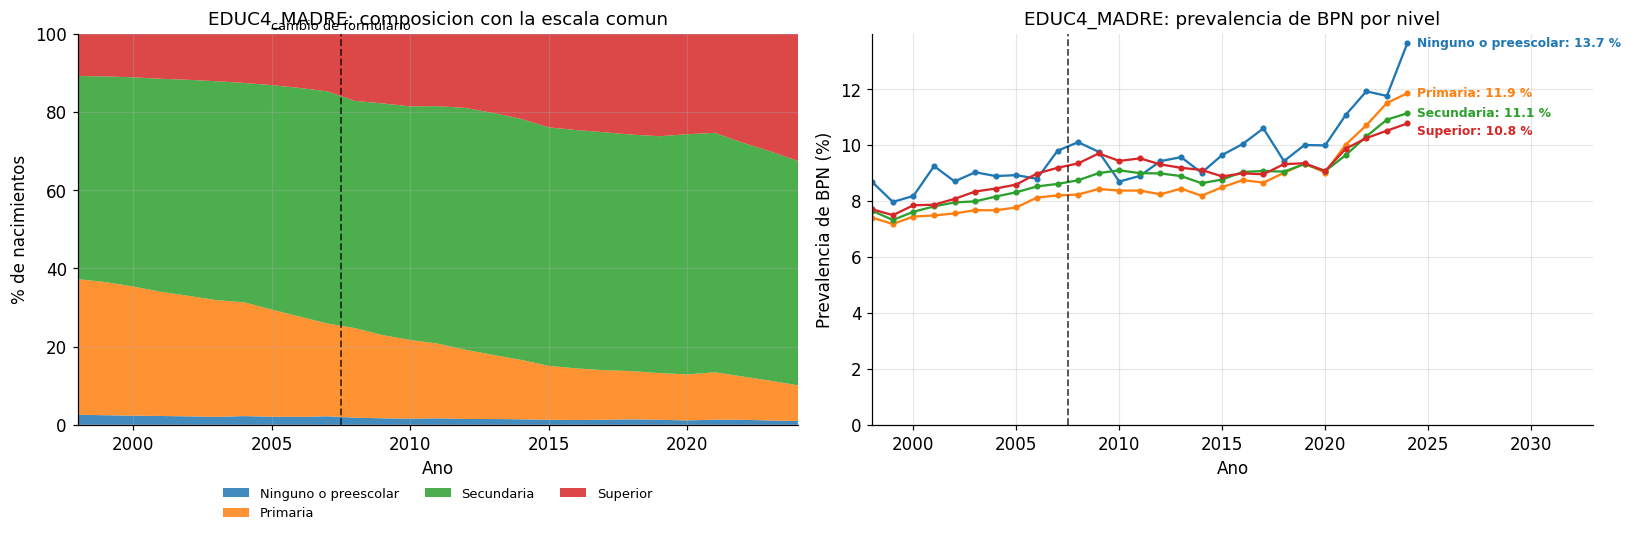

EDUC4_MADRE: cambio de composicion 1998-2024, en puntos porcentuales
   Primaria                                  -25.6 pp
   Ninguno o preescolar                       -1.6 pp
   Secundaria                                 +5.4 pp
   Superior                                  +21.7 pp

figura guardada: fig_armonizada_EDUC4_PADRE.pdf y fig_armonizada_EDUC4_PADRE.png


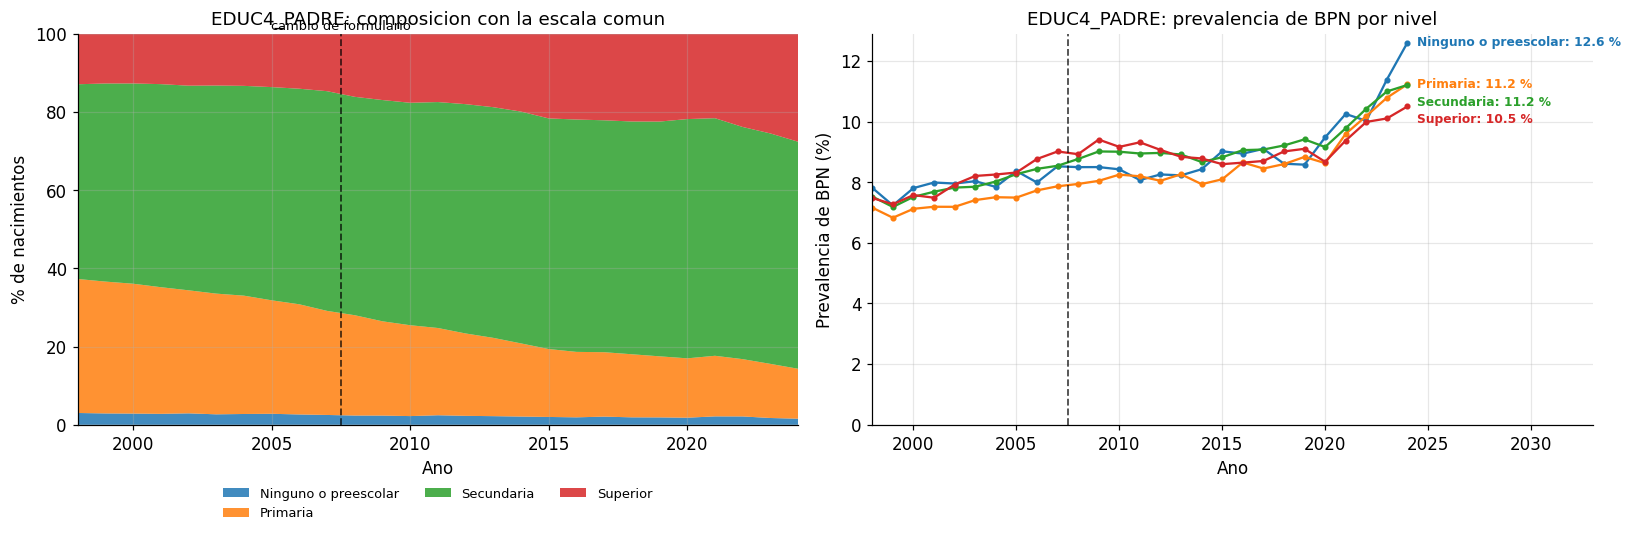

EDUC4_PADRE: cambio de composicion 1998-2024, en puntos porcentuales
   Primaria                                  -21.5 pp
   Ninguno o preescolar                       -1.5 pp
   Secundaria                                 +8.3 pp
   Superior                                  +14.7 pp

figura guardada: fig_armonizada_ESTCIV5.pdf y fig_armonizada_ESTCIV5.png


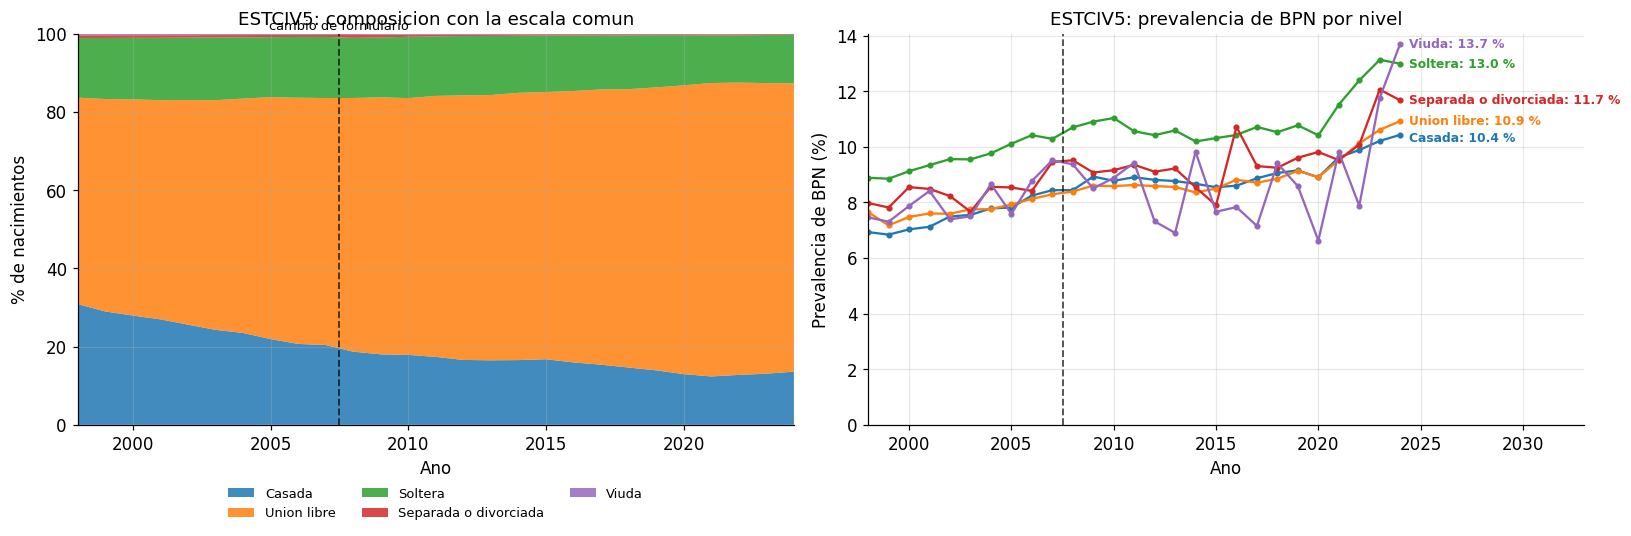

ESTCIV5: cambio de composicion 1998-2024, en puntos porcentuales
   Casada                                    -17.3 pp
   Soltera                                    -2.9 pp
   Separada o divorciada                      -0.5 pp
   Viuda                                      -0.3 pp
   Union libre                               +20.9 pp

figura guardada: fig_armonizada_SEG4.pdf y fig_armonizada_SEG4.png


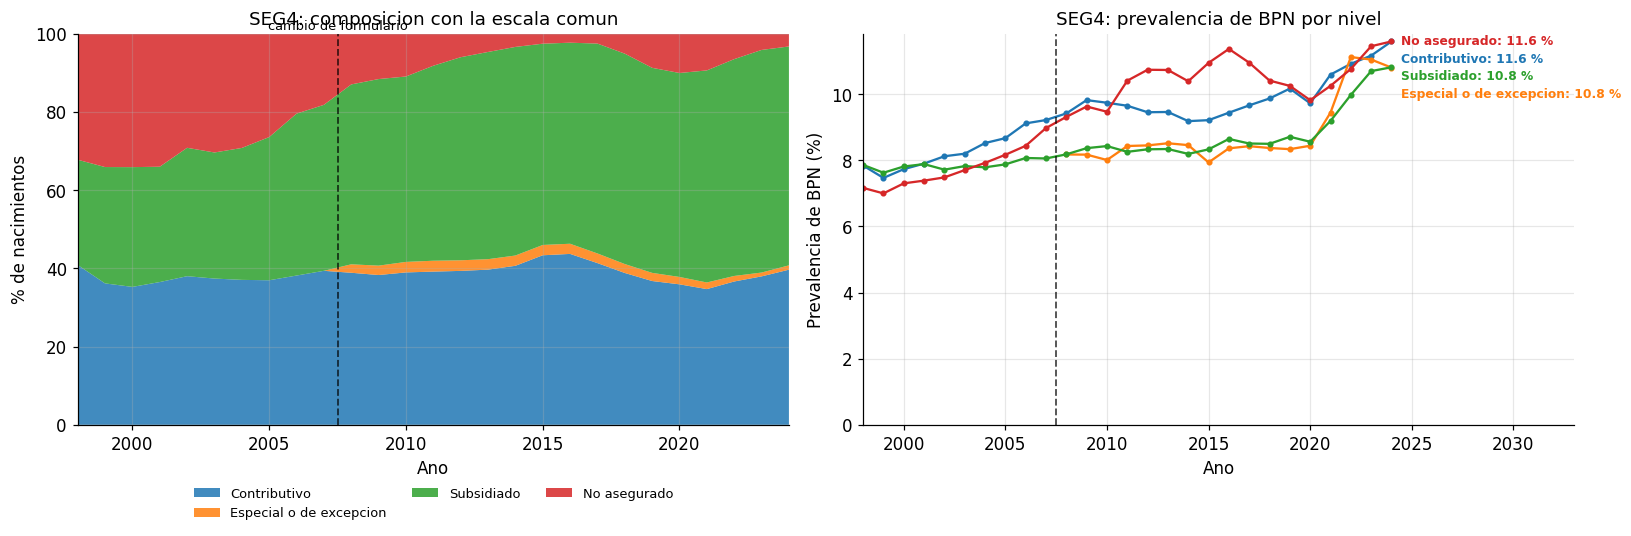

SEG4: cambio de composicion 1998-2024, en puntos porcentuales
   No asegurado                              -29.0 pp
   Contributivo                               -1.2 pp
   Especial o de excepcion                    +1.1 pp
   Subsidiado                                +29.1 pp



In [7]:
# ---------------------------------------------------------------------------
# Composicion anual con la escala comun
# ---------------------------------------------------------------------------

for nombre, escala in ARMONIZADAS:
    if nombre not in composiciones:
        continue
    comp = composiciones[nombre]
    etqs = armonizar.etiquetas_de(escala)

    # Prevalencia dentro de cada nivel, para el panel derecho.
    prev = (muestra.groupby(["ANIO", nombre], observed=True)["BPN"]
                   .mean().mul(100).unstack())

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # --- Panel izquierdo: composicion --------------------------------------
    # Ahora SI se etiquetan las franjas con el nombre de la categoria, no con
    # el codigo. Es lo que la armonizacion hace posible: el nivel significa lo
    # mismo en los 27 anios, de modo que rotularlo no afirma nada falso.
    axes[0].stackplot(comp.index, [comp[c] for c in comp.columns],
                      labels=[etqs.get(c, str(c)) for c in comp.columns],
                      alpha=0.85)
    axes[0].axvline(armonizar.ANIO_CORTE - 0.5, color="black",
                    linestyle="--", linewidth=1.2, alpha=0.7)
    # La anotacion va DENTRO del area de trazado, no encima. Antes se
    # colocaba en y=101, justo donde se compone el titulo, y los dos textos
    # se pisaban en el PNG exportado. El recuadro blanco la hace legible
    # sobre las bandas de color del stackplot.
    axes[0].annotate("cambio de formulario",
                     xy=(armonizar.ANIO_CORTE - 0.5, 96), ha="center",
                     va="top", fontsize=8.5, annotation_clip=False,
                     bbox=dict(boxstyle="round,pad=0.25", facecolor="white",
                               edgecolor="none", alpha=0.85))
    axes[0].set_ylim(0, 100)
    axes[0].set_xlim(comp.index.min(), comp.index.max())
    axes[0].set_title(f"{nombre}: composicion con la escala comun")
    axes[0].set_ylabel("% de nacimientos")
    axes[0].set_xlabel("Año de ocurrencia")
    axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, -0.13),
                   ncol=3, fontsize=8.5, frameon=False)

    # --- Panel derecho: prevalencia por nivel ------------------------------
    finales, colores = {}, {}
    for c in prev.columns:
        linea, = axes[1].plot(prev.index, prev[c], marker="o", markersize=3)
        serie = prev[c].dropna()
        if len(serie):
            texto = f"{etqs.get(c, c)}: {serie.iloc[-1]:.1f} %"
            finales[texto] = serie.iloc[-1]
            colores[texto] = linea.get_color()
    axes[1].axvline(armonizar.ANIO_CORTE - 0.5, color="black",
                    linestyle="--", linewidth=1.2, alpha=0.7)
    axes[1].set_title(f"{nombre}: prevalencia de BPN por nivel")
    axes[1].set_ylabel("Prevalencia de BPN (%)")
    axes[1].set_xlabel("Año de ocurrencia")
    axes[1].set_ylim(bottom=0)
    axes[1].set_xlim(prev.index.min(), prev.index.max() + 9)
    etiquetar_fin_de_linea(axes[1], finales, x=prev.index.max(),
                           colores=colores, tam=8)

    fig.tight_layout()
    guardar_figura(fig, f"fig_armonizada_{nombre}")
    plt.show()

    # Cambio de composicion entre los extremos de la serie. Ahora SI se puede
    # calcular: antes de armonizar, restar 2024 menos 1998 comparaba categorias
    # distintas y daba un numero vacio.
    cambio = (comp.iloc[-1] - comp.iloc[0]).sort_values()
    print(f"{nombre}: cambio de composicion 1998-2024, en puntos porcentuales")
    for nivel in cambio.index:
        print(f"   {etqs.get(nivel, nivel):<40} {cambio[nivel]:+6.1f} pp")
    print()

**Cómo se lee esta salida.**

**La línea vertical discontinua marca el cambio de formulario.** Es el punto donde, en las
figuras de la Fase 1, las franjas se reorganizaban de golpe. Aquí la composición debe
atravesarla sin discontinuidad.

**Ahora las franjas van rotuladas con el nombre de la categoría y no con el código.** Es
justamente lo que la armonización hace posible: el nivel significa lo mismo durante los 27
años, de modo que ponerle nombre ya no afirma nada falso sobre parte de la serie.

**Lo que el cambio de composición 1998-2024 dice, y que antes no se podía calcular.** En
educación materna, la expansión educativa colombiana debe verse como retroceso de los
niveles bajos y avance de superior. Esa es la cifra que va al Capítulo 5 y **sostiene el
argumento central del análisis de tendencia**: si la composición social de las madres mejoró
durante el período y la prevalencia de bajo peso al nacer aun así subió, el ascenso **no** se
explica por un empeoramiento de la estructura social de la población. Hay que buscarlo en
otra parte, y la cobertura del registro —con la correlación de −0,853 de la Fase 1— es el
primer candidato.

**Precaución sobre el panel derecho.** Son prevalencias crudas dentro de cada nivel, sin
ajustar por nada. Lo que se puede leer es si las líneas convergen, divergen o van en
paralelo. Atribuir a la educación lo que ahí se ve sería ignorar que las madres de distinta
educación difieren también en edad, territorio y paridad. Separar eso es la Fase 4.

## 7. El gradiente crudo, y un resultado que hay que saber defender

**Qué hacemos.** Prevalencia de bajo peso al nacer en cada nivel de las dos escalas
ordinales, sobre toda la serie.

**Por qué este bloque está aquí y no en la Fase 3.** Porque anticipa el resultado del índice
de concentración, y conviene llegar a esa fase sabiendo lo que va a salir en lugar de
descubrirlo con el índice ya calculado.

**La hipótesis de partida del trabajo** es la del gradiente social clásico: a menor posición
socioeconómica, mayor riesgo de bajo peso al nacer. En esa hipótesis, la prevalencia debería
descender de forma monótona del nivel 0 al nivel 3, y el índice de concentración de la
Fase 3 debería salir **negativo**.

**Lo que este bloque comprueba es si los datos crudos respaldan esa forma.** Si no lo hacen,
hay que entender por qué antes de calcular nada más.

In [8]:
# ---------------------------------------------------------------------------
# Gradiente crudo por nivel socioeconomico
# ---------------------------------------------------------------------------

ORDINALES = [("EDUC4_MADRE", "EDUC4"), ("SEGORD3", "SEGORD3")]

for nombre, escala in ORDINALES:
    if nombre not in muestra.columns:
        continue
    etqs = armonizar.etiquetas_de(escala)

    g = (muestra.groupby(nombre, observed=True)["BPN"]
                .agg(n="size", casos="sum"))
    g["prevalencia_pct"] = (g["casos"] / g["n"] * 100).round(2)
    g["pct_poblacion"] = (g["n"] / len(muestra) * 100).round(2)
    g["nivel"] = [etqs.get(i, str(i)) for i in g.index]

    g = g.reset_index()
    # `groupby` on pandas nullable integer columns can leave Int8Dtype in the index
    # or integer columns. NumPy-based export helpers reject those extension dtypes,
    # so coerce to plain NumPy dtypes before writing the CSV.
    for col in g.columns:
        if pd.api.types.is_integer_dtype(g[col].dtype):
            g[col] = pd.to_numeric(g[col], errors="coerce").astype("int64")
        elif pd.api.types.is_float_dtype(g[col].dtype):
            g[col] = pd.to_numeric(g[col], errors="coerce").astype("float64")
    guardar_tabla(g, f"gradiente_{nombre}", decimales=2)

    print(f"\n{'='*70}\n{nombre}  ({armonizar.ESCALAS[escala]['descripcion']})\n")
    print(g[["nivel", "n", "prevalencia_pct", "pct_poblacion"]]
          .to_string(index=False))

    # --- Forma del gradiente ------------------------------------------------
    # La pregunta no es si hay diferencias —con diecisiete millones de filas
    # siempre las hay— sino que FORMA tienen. Un gradiente social clasico es
    # monotono descendente al subir de nivel.
    p = g["prevalencia_pct"].to_numpy()
    diferencias = np.diff(p)
    if (diferencias < 0).all():
        forma = "MONOTONO DESCENDENTE (gradiente social clasico)"
    elif (diferencias > 0).all():
        forma = "MONOTONO ASCENDENTE (gradiente INVERTIDO)"
    else:
        forma = "NO MONOTONO"
    print(f"\n  forma            : {forma}")
    print(f"  nivel mas bajo   : {p[0]:.2f} %")
    print(f"  nivel mas alto   : {p[-1]:.2f} %")
    print(f"  diferencia       : {p[-1] - p[0]:+.2f} puntos porcentuales")
    print(f"  razon extremos   : {max(p) / min(p):.3f}")

tabla guardada: gradiente_EDUC4_MADRE.csv y gradiente_EDUC4_MADRE.tex

EDUC4_MADRE  (Nivel educativo alcanzado, escala comun de 4 niveles)

               nivel       n  prevalencia_pct  pct_poblacion
Ninguno o preescolar  288941             9.40           1.66
            Primaria 3510961             8.16          20.20
          Secundaria 9840986             8.80          56.63
            Superior 3179210             9.20          18.30

  forma            : NO MONOTONO
  nivel mas bajo   : 9.40 %
  nivel mas alto   : 9.20 %
  diferencia       : -0.20 puntos porcentuales
  razon extremos   : 1.152
tabla guardada: gradiente_SEGORD3.csv y gradiente_SEGORD3.tex

SEGORD3  (Aseguramiento como gradiente socioeconomico, 3 niveles ordenados)

                                nivel       n  prevalencia_pct  pct_poblacion
                         No asegurado 2525812             8.36          14.54
                           Subsidiado 7637958             8.52          43.95
Contributivo, esp

**Cómo se lee esta salida, y por qué es el bloque más importante del notebook.**

El resultado sobre los 17.376.860 registros:

**`EDUC4_MADRE`** — no monótono, con forma de U:

| Nivel | n | Prevalencia |
|---|---:|---:|
| Ninguno o preescolar | 288.941 | **9,40 %** |
| Primaria | 3.510.961 | **8,16 %** |
| Secundaria | 9.840.986 | 8,80 % |
| Superior | 3.179.210 | **9,20 %** |

**`SEGORD3`** — monótono, pero **en el sentido contrario al esperado**:

| Nivel | n | Prevalencia |
|---|---:|---:|
| No asegurado | 2.525.812 | 8,36 % |
| Subsidiado | 7.637.958 | 8,52 % |
| Contributivo, especial o de excepción | 6.758.590 | **9,27 %** |

**El gradiente no es el que predice la hipótesis.** En aseguramiento está claramente
invertido: la prevalencia más alta está en el régimen contributivo, que es el de mayor
posición socioeconómica. En educación, los dos extremos tienen prevalencia alta y el mínimo
está en primaria.

**Esto no es un error de la armonización.** La prueba de la frontera del bloque 5 ya descartó
que el mapeo esté mal, y el mismo patrón aparece en variables que **nunca necesitaron
armonizarse**: en `AREA_RES`, que es idéntica en los 27 años, la cabecera municipal tiene
prevalencia más alta que el rural disperso.

**La explicación que sostiene el trabajo es el sesgo de detección y registro.** Un nacimiento
de bajo peso tiene que ser **pesado, registrado y sobrevivir lo suficiente** para aparecer en
las estadísticas vitales. Las tres cosas dependen del acceso a atención médica:

- Un parto institucional pesa al recién nacido con báscula calibrada; uno domiciliario, a
  menudo no, y el peso se estima o se deja sin informar.
- Un prematuro extremo nacido donde hay unidad neonatal sobrevive y se registra como nacido
  vivo; sin ella, puede clasificarse como mortinato y salir del denominador.
- El registro civil es más completo donde el sistema de salud llega mejor.

Los tres mecanismos apuntan en la misma dirección: **donde hay más y mejor atención, se
detecta más bajo peso al nacer**. El gradiente observado mezcla el riesgo real con la
capacidad de observarlo, y con estos datos no se pueden separar.

**Esto es coherente con lo ya encontrado en la Fase 1**, y no es una explicación inventada
para este resultado: la correlación entre volumen del registro y prevalencia dio
**r = −0,853**, y la prevalencia nacional sube a lo largo del período en el que la cobertura
del registro y la atención institucional del parto mejoraron.

**Lo que hay que hacer con esto, en orden:**

1. **Consultarlo con el director antes de escribir el Capítulo 5.** Cambia el marco
   interpretativo de los resultados, no solo un párrafo.
2. **Esperar un índice de concentración positivo** en la Fase 3, y presentarlo como lo que
   es: la desigualdad en el **bajo peso registrado**, que no es lo mismo que la desigualdad
   en el bajo peso ocurrido.
3. **Convertirlo en el eje del análisis de sensibilidad de la Fase 6.** Restringir a partos
   institucionales, donde el pesaje es sistemático, es la comprobación natural: si el
   gradiente se atenúa o se invierte ahí, el sesgo de detección queda documentado con
   evidencia propia y deja de ser una conjetura.

**Un resultado contraintuitivo bien explicado vale más que uno esperado.** Lo que un jurado
sanciona no es que el gradiente salga invertido: es presentarlo sin haberlo visto venir, o
interpretarlo como si la posición socioeconómica alta fuera un factor de riesgo del bajo
peso al nacer.

**Correspondencia con el manuscrito.** Las dos tablas al Capítulo 5, Sección 5.1.3; la
discusión del sesgo de detección al Capítulo 6, junto a la limitación de cobertura del
registro que ya está declarada.

## 8. Cierre

**Qué hacemos.** Listamos lo producido e imprimimos las versiones de las bibliotecas.

**Por qué las versiones.** Un resultado que dentro de dos años no se reproduce es imposible
de diagnosticar sin saber con qué versiones se obtuvo.

In [9]:
# ---------------------------------------------------------------------------
# Cierre
# ---------------------------------------------------------------------------

from config import DIR_TABLAS, DIR_FIGURAS

print("INTERMEDIOS")
for f in sorted(DIR_INTERMEDIOS.glob("*.parquet")):
    print(f"  {f.name:<35} {f.stat().st_size / 1024**2:8.1f} MB")

print("\nTABLAS DE ESTE NOTEBOOK")
for nombre in ["codigos_en_conflicto", "escalas_comunes", "auditoria_mapeo",
               "prueba_frontera_2008", "gradiente_EDUC4_MADRE",
               "gradiente_SEGORD3"]:
    marca = "OK   " if (DIR_TABLAS / f"{nombre}.csv").exists() else "FALTA"
    print(f"  {marca}  {nombre}")

print("\nCOLUMNAS ARMONIZADAS DISPONIBLES PARA LAS FASES 3 A 7")
for nombre in ["EDUC4_MADRE", "EDUC4_PADRE", "ESTCIV5", "SEG4", "SEGORD3",
               "DPTO_RES", "MUNI_RES"]:
    if nombre in muestra.columns:
        print(f"  {nombre:<14} {muestra[nombre].notna().mean()*100:6.2f} % informado")

print("\n" + "=" * 60)
versiones()

INTERMEDIOS
  indices_desigualdad.parquet              0.0 MB
  muestra_analitica.parquet              232.5 MB
  muestra_armonizada.parquet             109.0 MB
  particion.parquet                        2.1 MB
  prevalencia_anual.parquet                0.0 MB
  prevalencia_departamento.parquet         0.0 MB
  prevalencia_municipal_anual.parquet      0.2 MB
  prevalencia_municipio.parquet            0.2 MB

TABLAS DE ESTE NOTEBOOK
  OK     codigos_en_conflicto
  OK     escalas_comunes
  OK     auditoria_mapeo
  OK     prueba_frontera_2008
  OK     gradiente_EDUC4_MADRE
  OK     gradiente_SEGORD3

COLUMNAS ARMONIZADAS DISPONIBLES PARA LAS FASES 3 A 7
  EDUC4_MADRE     96.80 % informado
  EDUC4_PADRE     88.35 % informado
  ESTCIV5         97.79 % informado
  SEG4            97.38 % informado
  SEGORD3         97.38 % informado
  DPTO_RES       100.00 % informado
  MUNI_RES       100.00 % informado

python 3.9.23
pandas       2.3.3
numpy        1.26.4
scipy        1.13.1
sklearn      1

## Qué sigue

**`03_desigualdad.ipynb`, Fase 3.** Índice de concentración y descomposición de la
desigualdad. Lee `intermedios/muestra_armonizada.parquet`, que este notebook acaba de dejar,
y ordena la población por `EDUC4_MADRE`.

Quien reproduzca este análisis debe comprobar antes estos cuatro puntos:

- [ ] Ningún código sin mapear salvo `SEG_SOCIAL` = 5 del período 1998-2007, el 0,79 %
- [ ] `frontera_anomala` es `False` en las cuatro variables
- [ ] La composición atraviesa 2008 sin escalón visible en las figuras del bloque 6
- [ ] `EDUC4_MADRE` y `SEGORD3` están marcadas como ordinales en el bloque 2

**Lo que este notebook deja planteado.** El gradiente crudo no tiene la forma que predice la
hipótesis del trabajo, y la explicación más plausible es el sesgo de detección y registro. Es
una decisión de marco interpretativo, no de código, y corresponde discutirla con el director
antes de redactar el Capítulo 5.

**Sobre el análisis de sensibilidad.** La escala detallada de 13 niveles sigue disponible en
`NIV_EDUM`, que se conservó sin recodificar en el archivo intermedio. La Fase 6 repite el
índice de concentración con ella sobre 2008-2024; si el signo y el orden de magnitud
coinciden con los de la escala común, la agregación no produjo el resultado.